---
title: Multi-feature inference
---

In [1]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, 
    ExpStepSize, ExpRegularization, clear_caches,
    Adam, Adagrad, RMSprop, SGDMomentum, Adamelia,
    SparseObservations, dense_to_sparse, is_sparse_observations,
)
import sys
import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from tqdm.auto import tqdm
from vscodenb import set_vscode_theme
sns.set_palette('tab10')
set_vscode_theme()
np.random.seed(17)


## Rewards

We can fit to reward transformed observations, like the total branch length of the coalescent. In the example below, we sample total branch lengths from the model and pass them to `svgd` along with the appropriate rewards.

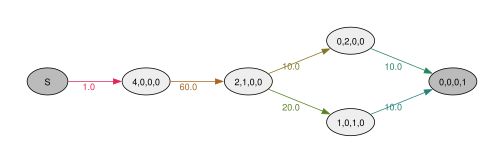

In [2]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

true_theta = [10]
graph = Graph(coalescent_1param) # should check using the graph hash if a trace of the graph is cached or available online
graph.update_weights(true_theta)
graph.plot()

In [3]:
rewards = graph.states().T
rewards = np.sum(rewards, axis=0)
nr_observations = 10000
observed_data = graph.sample(nr_observations, rewards=rewards)
observed_data

array([0.21821371, 0.47449114, 0.34667292, ..., 0.56767133, 0.20270889,
       0.46313372], shape=(10000,))

In [4]:
prior = GaussPrior(ci=[5, 25])
step_size = ExpStepSize(first_step=0.05, last_step=0.01, tau=30.0)

In [5]:
#graph.compute_trace()
svgd = graph.svgd(observed_data=observed_data, 
                  rewards=rewards,
                  prior=prior,
                #   learning_rate=step_size
                learning_rate=ExpStepSize(first_step=0.05, last_step=0.01, tau=30.0)
                    # optimizer=Adam(0.3),
                  )

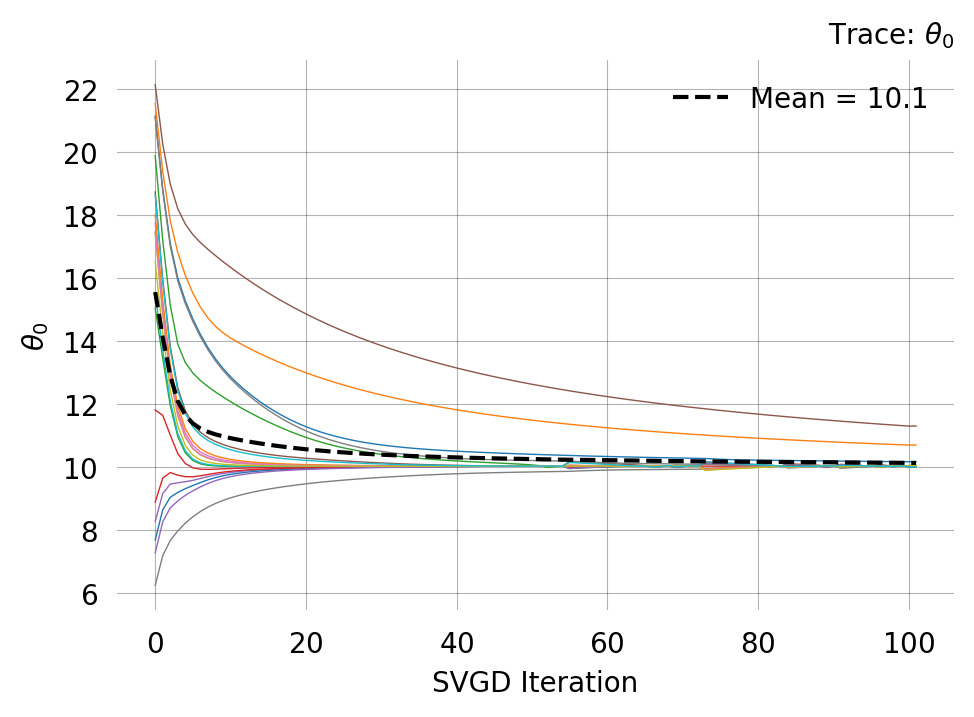

In [6]:
svgd.plot_trace() ;

In [7]:
svgd.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         10.02      10.12      0.3063     9.995        10.69       

Particles: 20, Iterations: 100


In [8]:
svgd.get_results()["theta_mean"].item()

10.118619640203688

In [9]:
svgd.map_estimate_from_particles()

([10.016633307465085], 2095.3077669038194)

## Multi-feature observations

Observations can be vectors of features, in which case you need to supply a set or rewards for each feature. The example below is the the same as above, except that we pass observations as single-value vectors.

In [10]:
# same as above
graph = Graph(coalescent_1param)
graph.update_weights(true_theta)

nr_observations = 10000

rewards = graph.states().T
rewards = np.sum(rewards, axis=0)
observed_data = graph.sample(nr_observations, rewards=rewards)

In [11]:

# make reward vector the only row of a 2d array
rewards = np.reshape(rewards, (-1, len(rewards))) 
# reshape data into a single-column 2d array
observed_data = np.reshape(observed_data, (len(observed_data), -1)) 

In [12]:

# #graph.compute_trace()
# svgd = graph.svgd(observed_data=observed_data, rewards=rewards, **params)
# svgd.get_results()["theta_mean"].item()

In [13]:
# svgd.map_estimate_from_particles()

With more than one feature, SVGD computes the likelihood for each feature using the the provided rewards. In this example, sample 1'ton, 2'ton, and 3'ton branch lengths are first, second and third observation features. The reward matrix passed to `svgd` must have as many rows as your data has features. Three rows in the reward matrix:

In [ ]:
graph = Graph(coalescent_1param)
graph.update_weights(true_theta)

# `graph.states().T` is the (n_features, n_vertices) reward matrix:
# each ROW is one feature's reward vector. The LAST row indexes the
# absorbing state — absorbing vertices have zero sojourn time, so
# rewarding them produces an identically-zero sample that carries no
# information about theta. Drop that row with `[:-1]`; `Graph.svgd`
# raises with a clear error if you forget.
#
# Among the remaining three rows, "feature 2" = `[0,0,0,0,1,0]`
# rewards only state 4, which some trajectories never visit. The
# resulting reward distribution has a point mass at zero;
# `Graph.svgd` handles this *partial coverage* automatically with a
# zero-inflated likelihood and emits a one-time UserWarning.
rewards = graph.states().T[:-1]
rewards


Data must be passed to `svgd` as a `SparseData` object. You can create it like this:


In [15]:
n = nr_observations
idxs = np.arange(rewards.shape[0])
feature_data = np.concatenate([graph.sample(n, rewards=rewards[i]) for i in idxs])
features = np.concatenate([[i]*n for i in idxs])
feature_slices = [(i*n, (i+1)*n) for i in idxs]

sparse_observations = SparseObservations(
    values=observed_data,
    features=features,
    n_features=3, 
    slices=feature_slices
)
sparse_observations

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_27506/896477865.py:3: UserWarning: rewards: not all trajectories accumulate positive reward. The resulting reward-transformed distribution is sub-stochastic; if you are using it for likelihood inference, Graph.svgd handles this automatically via a zero-inflated likelihood.
  feature_data = np.concatenate([graph.sample(n, rewards=rewards[i]) for i in idxs])


SparseObservations(values=<10000 values>, n_features=<3, features=<10000 values>, slices=<10000 values>)

It can also be created from a two-dimensional array where each row is an observation with all but a single non-nan value:

In [16]:
n = nr_observations
observed_data = np.zeros((n * (rewards.shape[0]), rewards.shape[0]), dtype=float)
observed_data[:] = np.nan
for i in range(rewards.shape[0]):
    observed_data[(i*n):((i+1)*n), i] = graph.sample(n, rewards=rewards[i])
np.random.shuffle(observed_data)
observed_data[:nr_observations] # just the first nr_observations rows
observed_data

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_27506/4284183897.py:5: UserWarning: rewards: not all trajectories accumulate positive reward. The resulting reward-transformed distribution is sub-stochastic; if you are using it for likelihood inference, Graph.svgd handles this automatically via a zero-inflated likelihood.
  observed_data[(i*n):((i+1)*n), i] = graph.sample(n, rewards=rewards[i])


array([[0.0571454 ,        nan,        nan,        nan],
       [0.19662329,        nan,        nan,        nan],
       [       nan,        nan,        nan, 0.        ],
       ...,
       [       nan,        nan,        nan, 0.        ],
       [       nan,        nan, 0.02484606,        nan],
       [       nan,        nan,        nan, 0.        ]], shape=(40000, 4))

In [17]:
sparse_observations = dense_to_sparse(observed_data)
sparse_observations

SparseObservations(values=<40000 values>, n_features=<4, features=<40000 values>, slices=<40000 values>)

::: {.callout-note }

## Reward-vector validity

`Graph.svgd` enforces two structural conditions on every feature:

1. **No absorbing-vertex rewards.** Absorbing vertices have zero
   sojourn time, so rewarding them carries no information about
   theta. `Graph.svgd` raises `ValueError` with a list of offending
   vertices. For `graph.states().T`, the last row indexes the
   absorbing state — drop it with `[:-1]`.

2. **Partial coverage is auto-handled.** When some absorbing
   trajectories never visit any vertex with reward > 0 in a feature,
   that feature's reward distribution has a point mass at zero.
   `Graph.svgd` detects this and switches to a zero-inflated
   likelihood: `n_zero · log(1 − p(θ)) + Σ log(pdf(r))`, where
   `p(θ) = P(visit a rewarded vertex)`. You see a one-time
   `UserWarning` naming the offending features.

To opt out of either check, pass `validate_rewards=False`.

:::

In [18]:
graph = Graph(coalescent_1param)

svgd = graph.svgd(observed_data=sparse_observations, 
                  rewards=rewards, 
                  prior=GaussPrior(ci=[1, 20]),  
                  n_iterations=500,                
            # learning_rate=ExpStepSize(first_step=0.01, last_step=0.001, tau=30.0)
                 optimizer=Adamelia(learning_rate=0.2)
                      )
svgd.summary()
svgd.plot_convergence() ;

/Users/kmt/phasic/.pixi/envs/default/lib/python3.13/site-packages/phasic/svgd.py:4136: SyntaxWarning: invalid escape sequence '\c'
  :math:`\theta^{(i)}_k = \theta_k \cdot \alpha_i`, with


KeyboardInterrupt: 

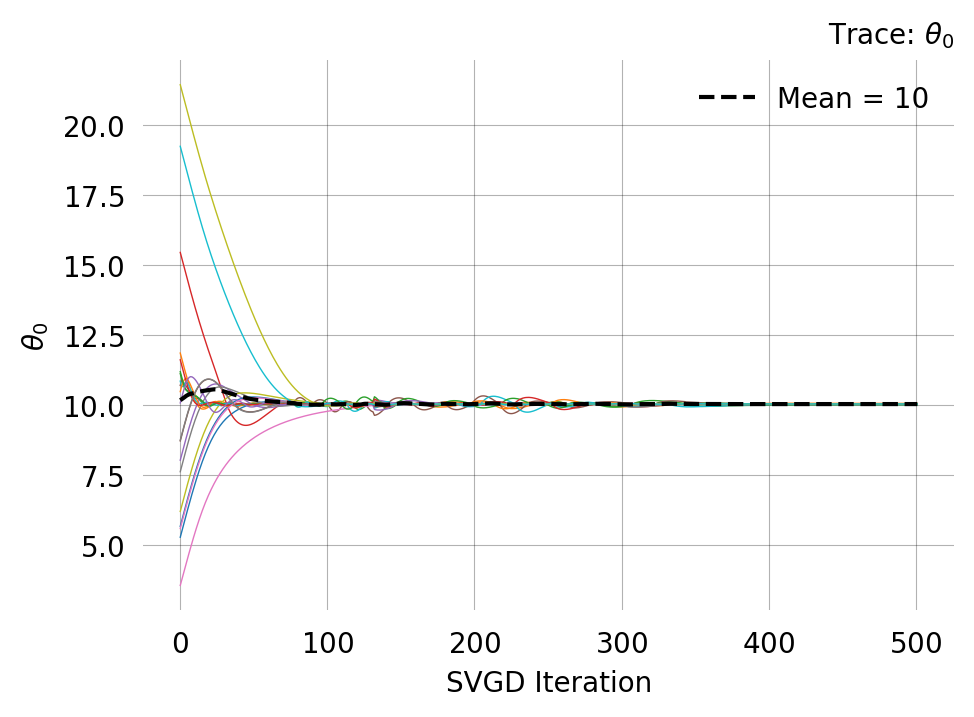

In [ ]:
svgd.plot_trace()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         9.952      9.734      0.5404     8.844        10          

Particles: 20, Iterations: 500


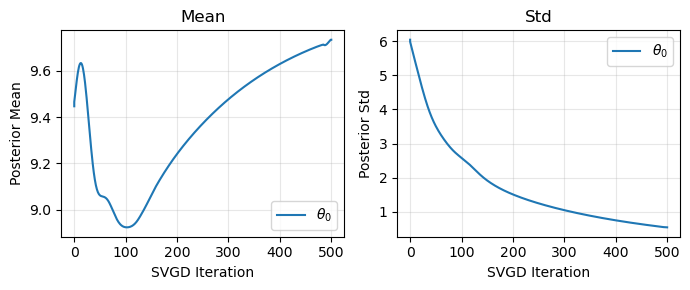

In [6]:
from phasic import (
    Graph, with_ipv, GaussPrior,
    ExpStepSize, Adamelia,
    SparseObservations, dense_to_sparse, 
)

import numpy as np

np.random.seed(17)

nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

true_theta = [10]

graph = Graph(coalescent_1param)
graph.update_weights(true_theta)


graph = Graph(coalescent_1param)
graph.update_weights(true_theta)

nr_observations = 10000

rewards = graph.states().T
rewards = rewards[:-1] # remove row for absorbing
rewards = np.sum(rewards, axis=0)
observed_data = graph.sample(nr_observations, rewards=rewards)

rewards = np.reshape(rewards, (-1, len(rewards))) 

observed_data = np.reshape(observed_data, (len(observed_data), -1)) 

graph = Graph(coalescent_1param)
graph.update_weights(true_theta)

# Use the full state decomposition. Features with partial coverage
# (i.e. rows whose reward vector is visited by only some absorbing
# trajectories) are handled by SVGD's zero-inflated likelihood — no
# manual feature selection needed.
rewards = graph.states().T
rewards = rewards[:-1] # remove row for absorbing
rewards

n = nr_observations
idxs = np.arange(rewards.shape[0])

feature_data = np.concatenate([graph.sample(n, rewards=rewards[i]) for i in idxs])
features = np.concatenate([[i]*n for i in idxs])
feature_slices = [(i*n, (i+1)*n) for i in idxs]

sparse_observations = SparseObservations(
    values=observed_data,
    features=features,
    n_features=rewards.shape[0], 
    slices=feature_slices
)

n = nr_observations
observed_data = np.zeros((n * (rewards.shape[0]), rewards.shape[0]), dtype=float)
observed_data[:] = np.nan
for i in range(rewards.shape[0]):
    observed_data[(i*n):((i+1)*n), i] = graph.sample(n, rewards=rewards[i])
np.random.shuffle(observed_data)
observed_data[:nr_observations]

sparse_observations = dense_to_sparse(observed_data)
sparse_observations 

graph = Graph(coalescent_1param)

svgd = graph.svgd(observed_data=sparse_observations, 
                  rewards=rewards, 
                  prior=GaussPrior(ci=[1, 20]),  
                  n_iterations=500,                
                #   learning_rate=ExpStepSize(first_step=0.01, last_step=0.001, tau=30.0)
                  optimizer=Adamelia(learning_rate=0.1)

                      )
svgd.summary()
svgd.plot_convergence() ;

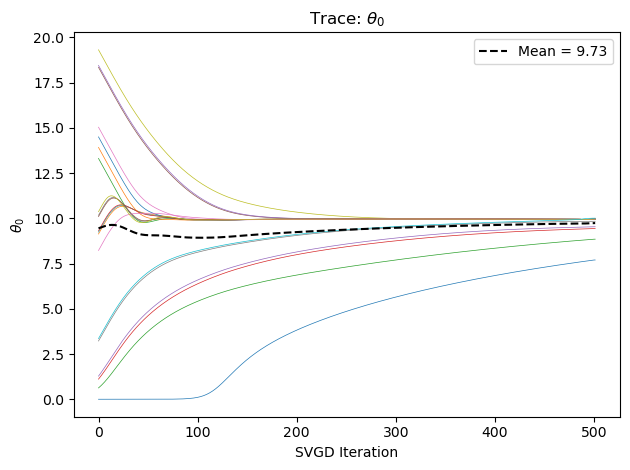

In [8]:
svgd.plot_trace()